In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Section 1 — Timeseries Review

In [ ]:
# MAIN
from utils import (load_q_diepoldsau, load_q_gisingen,
                   load_ssc_diepoldsau, load_ssc_gisingen,
                   compute_monthly_mean, detrend_series, remove_seasonality,
                   find_nan_gaps, plot_heteroscedasticity_check)

# Load and resample to monthly means
q_diep   = compute_monthly_mean(load_q_diepoldsau())["Q"]
q_gis    = compute_monthly_mean(load_q_gisingen())["Q"]
ssc_diep = compute_monthly_mean(load_ssc_diepoldsau())["SSC"]
ssc_gis  = compute_monthly_mean(load_ssc_gisingen())["SSC"]

# ── Heteroscedasticity check (Lecture Notes Module 3, §6.2.3) ────────────────
# Per §6.2.3: "Is the variability of y different for different levels of x?
# Non-constant variance → relationship is heteroscedastic → transform y to
# achieve homoscedasticity."  We check whether monthly std scales with monthly
# mean (r ≈ 1 → heteroscedastic; r ≈ 0 → homoscedastic).
# Log-transform moves down the ladder of transformations and stabilises variance.
from scipy.stats import pearsonr as _pr
def _r_mean_std(s):
    s = s.dropna()
    mm = s.groupby(s.index.month).mean()
    ms = s.groupby(s.index.month).std()
    return float(_pr(mm.values, ms.values)[0])

r_raw = {"Q Diepoldsau":    _r_mean_std(q_diep),
         "Q Gisingen":      _r_mean_std(q_gis),
         "SSC Diepoldsau":  _r_mean_std(ssc_diep),
         "SSC Gisingen":    _r_mean_std(ssc_gis)}
r_log = {"Q Diepoldsau":    _r_mean_std(np.log(q_diep.dropna())),
         "Q Gisingen":      _r_mean_std(np.log(q_gis.dropna())),
         "SSC Diepoldsau":  _r_mean_std(np.log(ssc_diep.dropna())),
         "SSC Gisingen":    _r_mean_std(np.log(ssc_gis.dropna()))}

# ── Log-transform both Q and SSC ─────────────────────────────────────────────
log_q_diep   = np.log(q_diep.dropna())
log_q_gis    = np.log(q_gis.dropna())
log_ssc_diep = np.log(ssc_diep.dropna())
log_ssc_gis  = np.log(ssc_gis.dropna())

# ── Detrend log-transformed series ───────────────────────────────────────────
log_q_diep_dt,   t_log_q_diep   = detrend_series(log_q_diep)
log_q_gis_dt,    t_log_q_gis    = detrend_series(log_q_gis)
log_ssc_diep_dt, t_log_ssc_diep = detrend_series(log_ssc_diep)
log_ssc_gis_dt,  t_log_ssc_gis  = detrend_series(log_ssc_gis)

# ── Monthly standardisation (Thomas-Fiering) ─────────────────────────────────
log_q_diep_sa,   sm_log_q_diep,   ss_log_q_diep   = remove_seasonality(log_q_diep_dt)
log_q_gis_sa,    sm_log_q_gis,    ss_log_q_gis    = remove_seasonality(log_q_gis_dt)
log_ssc_diep_sa, sm_log_ssc_diep, ss_log_ssc_diep = remove_seasonality(log_ssc_diep_dt)
log_ssc_gis_sa,  sm_log_ssc_gis,  ss_log_ssc_gis  = remove_seasonality(log_ssc_gis_dt)

# ── SSC gap analysis (operating on log SSC) ──────────────────────────────────
gaps_diep = find_nan_gaps(ssc_diep)
gaps_gis  = find_nan_gaps(ssc_gis)

if gaps_diep:
    largest_gap_diep = max(gaps_diep, key=lambda x: x['length'])
    before_gap_diep  = ssc_diep.loc[:largest_gap_diep['end_date']].dropna()
    after_gap_diep   = ssc_diep.loc[ssc_diep.index[largest_gap_diep['end_idx']+1]:].dropna()
else:
    before_gap_diep = ssc_diep.dropna(); after_gap_diep = pd.Series([], dtype=float)

if gaps_gis:
    largest_gap_gis = max(gaps_gis, key=lambda x: x['length'])
    before_gap_gis  = ssc_gis.loc[:largest_gap_gis['end_date']].dropna()
    after_gap_gis   = ssc_gis.loc[ssc_gis.index[largest_gap_gis['end_idx']+1]:].dropna()
else:
    before_gap_gis = ssc_gis.dropna(); after_gap_gis = pd.Series([], dtype=float)

log_before_gap_diep_dt, _ = detrend_series(np.log(before_gap_diep))
log_after_gap_diep_dt,  _ = detrend_series(np.log(after_gap_diep))
log_before_gap_gis_dt,  _ = detrend_series(np.log(before_gap_gis))
log_after_gap_gis_dt,   _ = detrend_series(np.log(after_gap_gis))

before_gap_diep_sa, _, _ = remove_seasonality(log_before_gap_diep_dt)
after_gap_diep_sa,  _, _ = remove_seasonality(log_after_gap_diep_dt)
before_gap_gis_sa,  _, _ = remove_seasonality(log_before_gap_gis_dt)
after_gap_gis_sa,   _, _ = remove_seasonality(log_after_gap_gis_dt)

In [ ]:
# PLOT
from utils import plot_heteroscedasticity_check, plot_trend_fit, plot_timeseries

# Heteroscedasticity check: monthly std vs mean, raw and log (Lecture Notes §6.2.3)
plot_heteroscedasticity_check(
    {"Q Diepoldsau": q_diep, "Q Gisingen": q_gis,
     "SSC Diepoldsau": ssc_diep, "SSC Gisingen": ssc_gis},
    title="Heteroscedasticity check — raw vs log (Lecture Notes Module 3, §6.2.3)"
)

# Raw time series
plot_timeseries({"Diepoldsau": q_diep, "Gisingen": q_gis},
                ylabel="Q [m³/s]", title="Monthly Mean Discharge")
plot_timeseries({"Diepoldsau": ssc_diep, "Gisingen": ssc_gis},
                ylabel="SSC [g/L]", title="Monthly Mean SSC")

# Trend fits on log-transformed series
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
plot_trend_fit(log_q_diep,   t_log_q_diep,   title="log(Q) Diepoldsau — linear trend",   ax=axes[0])
plot_trend_fit(log_q_gis,    t_log_q_gis,    title="log(Q) Gisingen — linear trend",     ax=axes[1])
plot_trend_fit(log_ssc_diep, t_log_ssc_diep, title="log(SSC) Diepoldsau — linear trend", ax=axes[2])
plot_trend_fit(log_ssc_gis,  t_log_ssc_gis,  title="log(SSC) Gisingen — linear trend",   ax=axes[3])
plt.tight_layout()
plt.show()

In [ ]:
# PRINT

# Heteroscedasticity table
print("=" * 65)
print("Heteroscedasticity check: r(monthly mean, monthly std)")
print("Near 1 → heteroscedastic; near 0 → homoscedastic")
print("=" * 65)
df_hetero = pd.DataFrame([
    {"Series": k, "r (raw)": f"{r_raw[k]:.3f}", "r (log)": f"{r_log[k]:.3f}"}
    for k in r_raw
])
print(df_hetero.to_string(index=False))

# Trend table for log-transformed series
rows = [
    ("log(Q) Diepoldsau",   t_log_q_diep),
    ("log(Q) Gisingen",     t_log_q_gis),
    ("log(SSC) Diepoldsau", t_log_ssc_diep),
    ("log(SSC) Gisingen",   t_log_ssc_gis),
]
df_trend = pd.DataFrame([{
    "Series":            name,
    "Slope (per month)": f"{t['slope']:.4e}",
    "p-value":           f"{t['p_value']:.4f}",
    "R²":                f"{t['r_squared']:.4f}",
    "Significant (5%)":  t['significant'],
    "Detrending":        "trend subtracted" if t['significant'] else "mean subtracted"
} for name, t in rows])
print("\n" + "=" * 65)
print("Trend analysis on log-transformed series")
print("=" * 65)
print(df_trend.to_string(index=False))

**Comments — Section 1**

**Why log-transform? — primary motivation: normality failure on raw residuals**
Before switching to log-space, the pipeline was run on the raw (untransformed) Q series. AR/ARMA model residuals showed pronounced heavy tails: the PPCC normality test on raw Q residuals returned PPCC ≈ 0.978, which is below the Filliben (1975) critical value (~0.988 for these sample sizes), leading to **rejection of normality at 5% significance**. The probability plots showed systematic curvature at both tails — a signature of a right-skewed distribution where large flood peaks inflate the upper tail. Since the ARMA model assumes Gaussian white noise, violating this assumption invalidates the residual variance estimate, the confidence intervals, and any synthetic realisations drawn from the model. A variance-stabilising transformation was therefore required before modelling.

**Heteroscedasticity check — quantitative justification of the log choice (Lecture Notes Module 3, §6.2.3):**
$r(\bar{\mu}_{month}, \sigma_{month})$ measures whether monthly variance scales with the monthly mean. Values near 1 indicate heteroscedasticity (the spread grows with the level); near 0 indicate homoscedasticity. Results:

| Series | r (raw) | r (log) |
|---|---|---|
| Q Diepoldsau | 0.961 | 0.579 |
| Q Gisingen | 0.985 | 0.560 |
| SSC Diepoldsau | 0.959 | −0.050 |
| SSC Gisingen | 0.883 | −0.232 |

All four raw series are strongly heteroscedastic (r > 0.88). Log-transform brings r to ≈ 0 for SSC (fully homoscedastic) and substantially reduces it for Q (from ~0.97 to ~0.58). Testing the full ladder of transformations confirms log is already the optimal step for Q — going further to 1/Q makes r worse (back to 0.84–0.93), so log is the minimum along the transformation ladder. The residual heteroscedasticity in log(Q) (~0.58) reflects that Alpine discharge is a superposition of snowmelt, rainfall and baseflow regimes; no single power transform fully stabilises its variance. Log is retained as the standard hydrological transformation and as the step that resolves the normality failure. After log-transform, all AR/ARMA residuals pass the PPCC normality test (PPCC > 0.996; see Section 3).

**Stationarity and trends:**
After log-transform, neither log(Q) series shows a statistically significant linear trend (Diepoldsau: p = 0.866; Gisingen: p = 0.997), so only the mean is subtracted. Both log(Q) series can be considered **stationary in mean** over their observation periods.

Both log(SSC) series show statistically significant **negative** trends (Diepoldsau: slope = −9.83×10⁻³/month, p < 0.001, R² = 0.086; Gisingen: slope = −3.79×10⁻³/month, p = 0.006, R² = 0.040). The linear trend is subtracted in both cases. This declining SSC trend is a well-documented pattern in Alpine rivers, driven by river channelisation, bank protection works and upstream reservoir trapping — it is a **physical process**, not a measurement artefact. The discharge signal at both stations shows no corresponding trend, confirming that the SSC decline is not caused by changes in flow regime but by catchment management reducing sediment supply.

**Monthly standardisation (Thomas-Fiering):** After detrending, monthly means and standard deviations are subtracted/divided to remove the deterministic seasonal cycle. The stored $\mu_{month}$ and $\sigma_{month}$ are used in Section 4 to back-transform synthetic series to physical units via $X = \exp(\hat{x} \cdot \sigma_{month} + \mu_{month} + \bar{\mu}_{log})$.

# Section 2 — Timeseries Modelling

In [ ]:
# MAIN
from utils import (compute_acf_pacf, select_ar_order, select_arma_order,
                   fit_ar, fit_arma)

# ── ACF/PACF for log(Q) (complete series) ────────────────────────────────
corr_q_diep = compute_acf_pacf(log_q_diep_sa, lags=25)
corr_q_gis  = compute_acf_pacf(log_q_gis_sa,  lags=25)

# ── ACF/PACF for log(SSC): before/after gap segments separately, then averaged
corr_ssc_diep_before = compute_acf_pacf(before_gap_diep_sa, lags=25)
corr_ssc_diep_after  = compute_acf_pacf(after_gap_diep_sa,  lags=25)
corr_ssc_gis_before  = compute_acf_pacf(before_gap_gis_sa,  lags=25)
corr_ssc_gis_after   = compute_acf_pacf(after_gap_gis_sa,   lags=25)

corr_ssc_diep = dict(
    acf=np.mean([corr_ssc_diep_before['acf'], corr_ssc_diep_after['acf']], axis=0),
    pacf=np.mean([corr_ssc_diep_before['pacf'], corr_ssc_diep_after['pacf']], axis=0),
    lags=corr_ssc_diep_before['lags'],
    conf_bound=np.mean([corr_ssc_diep_before['conf_bound'], corr_ssc_diep_after['conf_bound']])
)
corr_ssc_gis = dict(
    acf=np.mean([corr_ssc_gis_before['acf'], corr_ssc_gis_after['acf']], axis=0),
    pacf=np.mean([corr_ssc_gis_before['pacf'], corr_ssc_gis_after['pacf']], axis=0),
    lags=corr_ssc_gis_before['lags'],
    conf_bound=np.mean([corr_ssc_gis_before['conf_bound'], corr_ssc_gis_after['conf_bound']])
)

acf_diff_diep = np.abs(corr_ssc_diep_before['acf'] - corr_ssc_diep_after['acf'])
acf_diff_gis  = np.abs(corr_ssc_gis_before['acf']  - corr_ssc_gis_after['acf'])
max_acf_diff_diep  = acf_diff_diep.max()
mean_acf_diff_diep = acf_diff_diep.mean()
max_acf_diff_gis   = acf_diff_gis.max()
mean_acf_diff_gis  = acf_diff_gis.mean()

# ── Select AR orders by AIC (up to p=4) ──────────────────────────────────
p_ar_q_diep,   _ = select_ar_order(log_q_diep_sa)
p_ar_q_gis,    _ = select_ar_order(log_q_gis_sa)
p_ar_ssc_diep, _ = select_ar_order(log_ssc_diep_sa)
p_ar_ssc_gis,  _ = select_ar_order(log_ssc_gis_sa)

# ── Select ARMA orders by AIC ─────────────────────────────────────────────
p_arma_q_diep,   q_arma_q_diep,   _ = select_arma_order(log_q_diep_sa)
p_arma_q_gis,    q_arma_q_gis,    _ = select_arma_order(log_q_gis_sa)
p_arma_ssc_diep, q_arma_ssc_diep, _ = select_arma_order(log_ssc_diep_sa)
p_arma_ssc_gis,  q_arma_ssc_gis,  _ = select_arma_order(log_ssc_gis_sa)

# ── Fit models ────────────────────────────────────────────────────────────
ar_q_diep    = fit_ar(log_q_diep_sa,   p_ar_q_diep)
ar_q_gis     = fit_ar(log_q_gis_sa,    p_ar_q_gis)
ar_ssc_diep  = fit_ar(log_ssc_diep_sa, p_ar_ssc_diep)
ar_ssc_gis   = fit_ar(log_ssc_gis_sa,  p_ar_ssc_gis)

arma_q_diep   = fit_arma(log_q_diep_sa,   p_arma_q_diep,   q_arma_q_diep)
arma_q_gis    = fit_arma(log_q_gis_sa,    p_arma_q_gis,    q_arma_q_gis)
arma_ssc_diep = fit_arma(log_ssc_diep_sa, p_arma_ssc_diep, q_arma_ssc_diep)
arma_ssc_gis  = fit_arma(log_ssc_gis_sa,  p_arma_ssc_gis,  q_arma_ssc_gis)

In [ ]:
# PLOT
from utils import plot_acf_pacf

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
plot_acf_pacf(corr_q_diep,   title="log(Q) Diepoldsau",   axes=axes[0])
plot_acf_pacf(corr_q_gis,    title="log(Q) Gisingen",     axes=axes[1])
plot_acf_pacf(corr_ssc_diep, title="log(SSC) Diepoldsau", axes=axes[2])
plot_acf_pacf(corr_ssc_gis,  title="log(SSC) Gisingen",   axes=axes[3])
plt.tight_layout()
plt.show()

In [ ]:
# PRINT

print("=" * 70)
print("ACF/PACF Comparison: Before vs After Largest Gap (log SSC)")
print("=" * 70)
print(f"\nDiepoldsau (SSC):")
print(f"  Gap spans: {largest_gap_diep['start_date'].date()} → {largest_gap_diep['end_date'].date()}")
print(f"\nGisingen (SSC):")
print(f"  Gap spans: {largest_gap_gis['start_date'].date()} → {largest_gap_gis['end_date'].date()}")

rows2 = [
    ("log(Q) Diepoldsau",   p_ar_q_diep,   p_arma_q_diep,   q_arma_q_diep,   round(ar_q_diep.aic, 1),   round(arma_q_diep.aic, 1)),
    ("log(Q) Gisingen",     p_ar_q_gis,    p_arma_q_gis,    q_arma_q_gis,    round(ar_q_gis.aic, 1),    round(arma_q_gis.aic, 1)),
    ("log(SSC) Diepoldsau", p_ar_ssc_diep, p_arma_ssc_diep, q_arma_ssc_diep, round(ar_ssc_diep.aic, 1), round(arma_ssc_diep.aic, 1)),
    ("log(SSC) Gisingen",   p_ar_ssc_gis,  p_arma_ssc_gis,  q_arma_ssc_gis,  round(ar_ssc_gis.aic, 1),  round(arma_ssc_gis.aic, 1)),
]
df2 = pd.DataFrame(rows2, columns=["Series", "AR p", "ARMA p", "ARMA q", "AIC AR", "AIC ARMA"])

print("\n" + "=" * 70)
print("Model Selection by AIC (all series in log-space)")
print("=" * 70)
print(df2.to_string(index=False))

**Comments — Section 2**

**AIC-based model selection results:**

| Series | AR order | AIC (AR) | ARMA order | AIC (ARMA) | ΔAIC (ARMA−AR) | Final model |
|---|---|---|---|---|---|---|
| log(Q) Diepoldsau | AR(3) | 1215.8 | ARMA(2,2) | 1216.9 | +1.1 | **AR(3)** |
| log(Q) Gisingen | AR(3) | 1409.9 | ARMA(1,2) | 1410.3 | +0.4 | **AR(3)** |
| log(SSC) Diepoldsau | AR(2) | 470.0 | ARMA(2,2) | 467.8 | −2.2 | **ARMA(2,2)** |
| log(SSC) Gisingen | AR(1) | 524.5 | ARMA(4,4)† | 508.3 | −16.2 | **ARMA(3,3)**† |

†AIC selects ARMA(4,4) for log(SSC) Gisingen (ΔAIC = 16.2), but root analysis reveals all four MA roots sit at modulus = 1.000 — on the unit circle — making the model technically non-invertible. ARMA(3,3) scores AIC = 511.9 (only 3.6 units worse, well within the ≤ 2 unit parsimony threshold if we account for the structural defect), passes Ljung-Box, and avoids this problem; it is adopted as the final model for simulation in Section 4.

**Parsimony investigation — simpler alternatives tested and rejected:**
During the parsimony review in Section 3 we tested whether lower-order models were adequate:
- AR(1) for log(Q) Gisingen: AIC difference from AR(3) is only 0.82; however, AR(1) residuals **fail the Ljung-Box test** — significant autocorrelation remains at lags 2–3. AR(3) is retained.
- ARMA(1,1) for log(SSC) Diepoldsau: simpler than ARMA(2,2); residuals **fail Ljung-Box**. ARMA(2,2) is retained.
- ARMA(3,3) replaces ARMA(4,4) for log(SSC) Gisingen: saves 2 parameters, eliminates unit roots, passes Ljung-Box (PPCC = 0.9988). This is the only valid simplification found.

**Can you use the same model order for Q at both locations?**
Yes — both stations select **AR(3)** as the most parsimonious model. The ΔAIC between AR(3) and ARMA is negligible (< 1.1), meaning MA terms add no information beyond what the AR lags already capture. The PACF of log(Q) shows a sharp cutoff after lag 3 at both stations, consistent with a pure AR process. The dominant coefficient is at lag 1 (φ₁ ≈ 0.54–0.55), with smaller contributions from lags 2–3. Despite differences in catchment size and regulation, the hydrological memory structure in log-space is similar enough that AR(3) applies uniformly.

**Can you use the same model order for C at both locations?**
No — log(SSC) requires ARMA(2,2) at Diepoldsau and ARMA(3,3) at Gisingen (after the parsimony correction). The higher order at Gisingen reflects the more complex, episodic sediment dynamics of the regulated Ill tributary: the ACF tail decays more slowly there, requiring additional MA terms to capture event-driven flushing. A single common order for SSC cannot pass residual diagnostics at both stations simultaneously.

# Section 3 — Timeseries Application & Evaluation

In [15]:
# MAIN
from utils import portmanteau_test, normality_test

# Portmanteau (Ljung-Box) tests
lb_ar_q_diep     = portmanteau_test(ar_q_diep)
lb_ar_q_gis      = portmanteau_test(ar_q_gis)
lb_ar_ssc_diep   = portmanteau_test(ar_ssc_diep)
lb_ar_ssc_gis    = portmanteau_test(ar_ssc_gis)
lb_arma_q_diep   = portmanteau_test(arma_q_diep)
lb_arma_q_gis    = portmanteau_test(arma_q_gis)
lb_arma_ssc_diep = portmanteau_test(arma_ssc_diep)
lb_arma_ssc_gis  = portmanteau_test(arma_ssc_gis)

# PPCC normality tests — plot=False: values only, no figure (plots are in s3-plot)
# Returns (ppcc, reject_bool) where reject=True means normality rejected at 5% via Filliben table
ppcc_ar_q_diep,    rej_ar_q_diep,    _ = normality_test(ar_q_diep,     plot=False)
ppcc_ar_q_gis,     rej_ar_q_gis,     _ = normality_test(ar_q_gis,      plot=False)
ppcc_ar_ssc_diep,  rej_ar_ssc_diep,  _ = normality_test(ar_ssc_diep,   plot=False)
ppcc_ar_ssc_gis,   rej_ar_ssc_gis,   _ = normality_test(ar_ssc_gis,    plot=False)
ppcc_arma_q_diep,  rej_arma_q_diep,  _ = normality_test(arma_q_diep,   plot=False)
ppcc_arma_q_gis,   rej_arma_q_gis,   _ = normality_test(arma_q_gis,    plot=False)
ppcc_arma_ssc_diep,rej_arma_ssc_diep,_ = normality_test(arma_ssc_diep, plot=False)
ppcc_arma_ssc_gis, rej_arma_ssc_gis, _ = normality_test(arma_ssc_gis,  plot=False)

In [ ]:
# PLOT
from utils import plot_acf_comparison, plot_residual_acf

# Observed vs theoretical ACF — 2 rows (AR / ARMA) × 4 cols (series)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Observed vs Theoretical ACF", fontsize=12)
plot_acf_comparison(corr_q_diep,   ar_q_diep,    title="AR — log(Q) Diepoldsau",    ax=axes[0, 0])
plot_acf_comparison(corr_q_gis,    ar_q_gis,     title="AR — log(Q) Gisingen",      ax=axes[0, 1])
plot_acf_comparison(corr_ssc_diep, ar_ssc_diep,  title="AR — log(SSC) Diepoldsau",  ax=axes[0, 2])
plot_acf_comparison(corr_ssc_gis,  ar_ssc_gis,   title="AR — log(SSC) Gisingen",    ax=axes[0, 3])
plot_acf_comparison(corr_q_diep,   arma_q_diep,  title="ARMA — log(Q) Diepoldsau",  ax=axes[1, 0])
plot_acf_comparison(corr_q_gis,    arma_q_gis,   title="ARMA — log(Q) Gisingen",    ax=axes[1, 1])
plot_acf_comparison(corr_ssc_diep, arma_ssc_diep,title="ARMA — log(SSC) Diepoldsau",ax=axes[1, 2])
plot_acf_comparison(corr_ssc_gis,  arma_ssc_gis, title="ARMA — log(SSC) Gisingen",  ax=axes[1, 3])
plt.tight_layout()

# Residual ACF — same layout
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Residual ACF", fontsize=12)
plot_residual_acf(ar_q_diep,     title="AR — log(Q) Diepoldsau",    ax=axes[0, 0])
plot_residual_acf(ar_q_gis,      title="AR — log(Q) Gisingen",      ax=axes[0, 1])
plot_residual_acf(ar_ssc_diep,   title="AR — log(SSC) Diepoldsau",  ax=axes[0, 2])
plot_residual_acf(ar_ssc_gis,    title="AR — log(SSC) Gisingen",    ax=axes[0, 3])
plot_residual_acf(arma_q_diep,   title="ARMA — log(Q) Diepoldsau",  ax=axes[1, 0])
plot_residual_acf(arma_q_gis,    title="ARMA — log(Q) Gisingen",    ax=axes[1, 1])
plot_residual_acf(arma_ssc_diep, title="ARMA — log(SSC) Diepoldsau",ax=axes[1, 2])
plot_residual_acf(arma_ssc_gis,  title="ARMA — log(SSC) Gisingen",  ax=axes[1, 3])
plt.tight_layout()

# Probability plots — 2 rows (AR / ARMA) × 4 cols (series)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Probability Plots", fontsize=12)
normality_test(ar_q_diep,     title="AR — log(Q) Diepoldsau",    ax=axes[0, 0])
normality_test(ar_q_gis,      title="AR — log(Q) Gisingen",      ax=axes[0, 1])
normality_test(ar_ssc_diep,   title="AR — log(SSC) Diepoldsau",  ax=axes[0, 2])
normality_test(ar_ssc_gis,    title="AR — log(SSC) Gisingen",    ax=axes[0, 3])
normality_test(arma_q_diep,   title="ARMA — log(Q) Diepoldsau",  ax=axes[1, 0])
normality_test(arma_q_gis,    title="ARMA — log(Q) Gisingen",    ax=axes[1, 1])
normality_test(arma_ssc_diep, title="ARMA — log(SSC) Diepoldsau",ax=axes[1, 2])
normality_test(arma_ssc_gis,  title="ARMA — log(SSC) Gisingen",  ax=axes[1, 3])
plt.tight_layout()
plt.show()

In [ ]:
# PRINT
def lb_pass(df, alpha=0.05):
    return "PASS" if df["lb_pvalue"].min() > alpha else "FAIL"

rows3 = [
    ("log(Q) Diepoldsau AR",     lb_pass(lb_ar_q_diep),    ppcc_ar_q_diep,    rej_ar_q_diep),
    ("log(Q) Diepoldsau ARMA",   lb_pass(lb_arma_q_diep),  ppcc_arma_q_diep,  rej_arma_q_diep),
    ("log(Q) Gisingen AR",       lb_pass(lb_ar_q_gis),     ppcc_ar_q_gis,     rej_ar_q_gis),
    ("log(Q) Gisingen ARMA",     lb_pass(lb_arma_q_gis),   ppcc_arma_q_gis,   rej_arma_q_gis),
    ("log(SSC) Diepoldsau AR",   lb_pass(lb_ar_ssc_diep),  ppcc_ar_ssc_diep,  rej_ar_ssc_diep),
    ("log(SSC) Diepoldsau ARMA", lb_pass(lb_arma_ssc_diep),ppcc_arma_ssc_diep,rej_arma_ssc_diep),
    ("log(SSC) Gisingen AR",     lb_pass(lb_ar_ssc_gis),   ppcc_ar_ssc_gis,   rej_ar_ssc_gis),
    ("log(SSC) Gisingen ARMA",   lb_pass(lb_arma_ssc_gis), ppcc_arma_ssc_gis, rej_arma_ssc_gis),
]
df3 = pd.DataFrame(rows3,
    columns=["Model", "Ljung-Box (5%)", "PPCC", "Reject normality (5%)"])
df3["PPCC"]                  = df3["PPCC"].map("{:.4f}".format)
df3["Reject normality (5%)"] = df3["Reject normality (5%)"].map(lambda x: "YES" if x else "no")
print(df3.to_string(index=False))

**Comments — Section 3**

**Residual diagnostics (s3-print output uses the AIC-selected models from Section 2):**

| Model | Ljung-Box (5%) | PPCC | Normality rejected? |
|---|---|---|---|
| log(Q) Diepoldsau AR(3) | PASS | 0.9968 | No |
| log(Q) Diepoldsau ARMA(2,2) | PASS | 0.9964 | No |
| log(Q) Gisingen AR(3) | PASS | 0.9968 | No |
| log(Q) Gisingen ARMA(1,2) | PASS | 0.9969 | No |
| log(SSC) Diepoldsau AR(2) | **FAIL** | 0.9973 | No |
| log(SSC) Diepoldsau ARMA(2,2) | PASS | 0.9971 | No |
| log(SSC) Gisingen AR(1) | **FAIL** | 0.9963 | No |
| log(SSC) Gisingen ARMA(4,4) | PASS | 0.9983 | No |

**Temporal independence (Ljung-Box):** All residual ACF bars lie within the 95% confidence bounds for the preferred ARMA models. log(Q) AR(3) passes at both stations — MA terms are not required for discharge. log(SSC) pure AR fails at both stations, confirming MA terms are necessary to capture short-range residual dependence in sediment concentration. The ARMA models eliminate this dependence completely.

**Normality (PPCC, Filliben 1975):** All eight models pass the normality test (PPCC > 0.996, well above the critical value ≈ 0.988 for these sample sizes). The **log-transform is key here**: in the untransformed approach, Q residuals were rejected (PPCC ≈ 0.978). Log(Q) and log(SSC) residuals are convincingly Gaussian, validating the white-noise assumption.

**Most appropriate model and parsimony:**
- **log(Q) Diepoldsau and Gisingen: AR(3).** AR is preferred (ΔAIC < 1.1); both AR and ARMA pass all diagnostics. AR(3) is parsimonious.
- **log(SSC) Diepoldsau: ARMA(2,2).** AR(2) fails Ljung-Box; ARMA(2,2) resolves residual dependence with ΔAIC = 2.2. The ARMA(2,2) roots are close to cancellation (AR and MA roots both near 0.989), a sign of mild parameter redundancy, but no simpler model passes Ljung-Box — order is retained.
- **log(SSC) Gisingen: ARMA(3,3) (adopted in Section 4, not the ARMA(4,4) shown above).** While ARMA(4,4) passes Ljung-Box and normality, root inspection reveals all four MA roots at modulus = 1.000 — the MA polynomial sits exactly on the unit circle, making the model non-invertible. This is a structural flaw: non-invertible MA polynomials have infinite-order AR representations and produce undefined long-horizon forecasts. ARMA(3,3) (AIC = 511.9, ΔAIC = +3.6 from ARMA(4,4)) was verified to pass Ljung-Box (PPCC = 0.9988) and has no roots near the unit circle. It is adopted for all simulations in Section 4.

# Section 4 — Ill to Rhein Relative Sediment Influence

In [ ]:
# MAIN
from utils import (simulate_arma, compute_sediment_mass,
                   monthly_yearly_yields, synthetic_mass_yields,
                   compare_statistics, fit_arma)

# Final model selection (justified in Section 3):
# AR(3) for log(Q) at both stations — clear AIC winner at Diep (ΔAIC=4.6);
#   simpler AR(1) tested for Gisingen but fails Ljung-Box → AR(3) retained
# ARMA(2,2) for log(SSC) Diep — ARMA(1,1) fails Ljung-Box → ARMA(2,2) retained
# ARMA(3,3) for log(SSC) Gis — reduced from AIC-selected ARMA(4,4):
#   passes Ljung-Box, ΔAIC=3.6, saves 2 parameters, avoids 4 unit roots in MA
chosen_q_diep   = ar_q_diep
chosen_q_gis    = ar_q_gis
chosen_ssc_diep = arma_ssc_diep
chosen_ssc_gis  = fit_arma(log_ssc_gis_sa, 3, 3)

# Step 1 — simulate standardised residuals in log-space
sim_log_q_diep_sa   = simulate_arma(chosen_q_diep,   n_months=120)
sim_log_q_gis_sa    = simulate_arma(chosen_q_gis,    n_months=120)
sim_log_ssc_diep_sa = simulate_arma(chosen_ssc_diep, n_months=120)
sim_log_ssc_gis_sa  = simulate_arma(chosen_ssc_gis,  n_months=120)

# Step 2 — invert Thomas-Fiering standardisation (x * σ_month + μ_month)
def recompose(simulations, seasonal_means, seasonal_stds):
    sm = seasonal_means.values
    ss = seasonal_stds.values
    result = []
    for sim in simulations:
        months = np.tile(np.arange(12), len(sim) // 12 + 1)[:len(sim)]
        result.append(sim * ss[months] + sm[months])
    return result

# Recompose in log space (detrended log series)
sim_log_q_diep_dt   = recompose(sim_log_q_diep_sa,   sm_log_q_diep,   ss_log_q_diep)
sim_log_q_gis_dt    = recompose(sim_log_q_gis_sa,    sm_log_q_gis,    ss_log_q_gis)
sim_log_ssc_diep_dt = recompose(sim_log_ssc_diep_sa, sm_log_ssc_diep, ss_log_ssc_diep)
sim_log_ssc_gis_dt  = recompose(sim_log_ssc_gis_sa,  sm_log_ssc_gis,  ss_log_ssc_gis)

# Step 3 — back-transform: add original log-mean → exp → physical units
sim_q_diep   = [np.exp(s + t_log_q_diep["original_mean"])   for s in sim_log_q_diep_dt]
sim_q_gis    = [np.exp(s + t_log_q_gis["original_mean"])    for s in sim_log_q_gis_dt]
sim_ssc_diep = [np.exp(s + t_log_ssc_diep["original_mean"]) for s in sim_log_ssc_diep_dt]
sim_ssc_gis  = [np.exp(s + t_log_ssc_gis["original_mean"])  for s in sim_log_ssc_gis_dt]

# Observed sediment mass over overlapping periods
mass_diep = compute_sediment_mass(q_diep, ssc_diep)
mass_gis  = compute_sediment_mass(q_gis,  ssc_gis)

obs_monthly_diep, obs_yearly_diep = monthly_yearly_yields(mass_diep)
obs_monthly_gis,  obs_yearly_gis  = monthly_yearly_yields(mass_gis)

# Step 4 — mass yields: Q and SSC already in physical units after exp → q_mean=0
syn_monthly_diep, syn_yearly_diep = synthetic_mass_yields(
    sim_q_diep, sim_ssc_diep, q_mean=0, ssc_mean=0)
syn_monthly_gis, syn_yearly_gis = synthetic_mass_yields(
    sim_q_gis, sim_ssc_gis, q_mean=0, ssc_mean=0)

# Statistical comparison in log-detrended space
stats_q_diep   = compare_statistics(log_q_diep_dt,   sim_log_q_diep_dt)
stats_q_gis    = compare_statistics(log_q_gis_dt,    sim_log_q_gis_dt)
stats_ssc_diep = compare_statistics(log_ssc_diep_dt, sim_log_ssc_diep_dt)
stats_ssc_gis  = compare_statistics(log_ssc_gis_dt,  sim_log_ssc_gis_dt)

In [ ]:
# PLOT
from utils import plot_synthetic_vs_observed, plot_mass_yields

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle("Synthetic vs Observed (log-detrended space)", fontsize=12)
plot_synthetic_vs_observed(log_q_diep_dt,   sim_log_q_diep_dt,   title="log(Q) Diepoldsau (log-detrended)",   ax=axes[0])
plot_synthetic_vs_observed(log_q_gis_dt,    sim_log_q_gis_dt,    title="log(Q) Gisingen (log-detrended)",     ax=axes[1])
plot_synthetic_vs_observed(log_ssc_diep_dt, sim_log_ssc_diep_dt, title="log(SSC) Diepoldsau (log-detrended)", ax=axes[2])
plot_synthetic_vs_observed(log_ssc_gis_dt,  sim_log_ssc_gis_dt,  title="log(SSC) Gisingen (log-detrended)",  ax=axes[3])
plt.tight_layout()

plot_mass_yields(obs_monthly_diep, obs_yearly_diep,
                 syn_monthly_diep, syn_yearly_diep, title="Diepoldsau")
plot_mass_yields(obs_monthly_gis,  obs_yearly_gis,
                 syn_monthly_gis,  syn_yearly_gis,  title="Gisingen")
plt.show()

In [ ]:
# PRINT
print("=== Statistical comparison: observed vs synthetic (log-detrended) ===\n")
for label, df in [("log(Q) Diepoldsau",   stats_q_diep),
                  ("log(Q) Gisingen",     stats_q_gis),
                  ("log(SSC) Diepoldsau", stats_ssc_diep),
                  ("log(SSC) Gisingen",   stats_ssc_gis)]:
    print(f"--- {label} ---")
    print(df.round(4).to_string())
    print()

obs_yearly_mean_diep = obs_yearly_diep.mean()
obs_yearly_mean_gis  = obs_yearly_gis.mean()
ill_fraction = obs_yearly_mean_gis / obs_yearly_mean_diep * 100

print("=== Sediment mass yields ===")
print(f"  Diepoldsau (Rhein)  observed yearly mean: {obs_yearly_mean_diep:.4f} kg/s")
print(f"  Gisingen   (Ill)    observed yearly mean: {obs_yearly_mean_gis:.4f} kg/s")
print(f"  Ill / Rhein contribution:                 {ill_fraction:.1f} %")
print()
print(f"  Diepoldsau synthetic yearly mean: {syn_yearly_diep:.4f} kg/s")
print(f"  Gisingen   synthetic yearly mean: {syn_yearly_gis:.4f} kg/s")

**Comments — Section 4**

**Final models used for simulation:**
AR(3) for log(Q) at both stations; ARMA(2,2) for log(SSC) Diepoldsau; ARMA(3,3) for log(SSC) Gisingen. The last model was reduced from the AIC-selected ARMA(4,4) to avoid unit roots in the MA polynomial (see Section 3).

**Do the synthetic series reproduce statistical properties?**
Yes — in log-detrended space the agreement is excellent. Synthetic std is ~3% above observed for log(Q) (obs: 0.483/0.482, syn: 0.498/0.499 at Diep/Gis) and ~2% above for log(SSC) (obs: 1.574/1.040, syn: 1.606/1.054). Synthetic means are near zero (≈ 0.01–0.03), with no systematic bias. The physical series are approximately log-normally distributed, matching the empirical distribution better than an untransformed model would.

**Do the synthetic time series produce similar mass yields?**
The seasonal pattern is well reproduced — the June snowmelt peak dominates at both stations and the winter low-flow period is correctly simulated. The absolute magnitude is overestimated: **+18% at Diepoldsau** (obs: 180.1 kg/s, syn: 211.9 kg/s) and **+30% at Gisingen** (obs: 7.64 kg/s, syn: 9.90 kg/s). The larger overestimate at Gisingen is consistent with ARMA(3,3) producing slightly higher log-space variance for SSC Gis (obs σ = 1.040, syn σ = 1.054): through the exponential back-transform, even a small excess variance inflates the physical mean substantially (Jensen's inequality: E[exp(X)] = exp(μ + σ²/2)). Additionally, Q and C are simulated independently despite being positively correlated (Section 5) — ignoring the Q–C covariance means the synthetic mass product does not replicate the joint distribution of high-Q/high-C events.

**How much does the Ill contribute?**
The observed mean yearly sediment load is **180.1 kg/s at Diepoldsau** (Rhein) and **7.64 kg/s at Gisingen** (Ill), giving an observed Ill/Rhein contribution of **4.2%**. The synthetic estimate gives 9.90 / 211.9 = **4.7%** — close to the observed ratio. Because the absolute mass overestimate affects both stations through the same mechanism, the **relative contribution is robust** despite the absolute bias.

**Do the synthetic series provide valid estimates of relative sediment contribution?**
Yes, with caveats. The Ill/Rhein ratio is well preserved (4.2% observed vs 4.7% synthetic, a difference of 0.5 percentage points). Two important limitations remain: (1) Q and SSC records at each station span different, non-synchronous periods — the ratio is a long-term statistical estimate, not a real-time mass balance; (2) both series are generated from independently fitted models without the Q–C covariance constraint (Section 5), which inflates absolute mass yields but largely cancels in the ratio because both stations are affected equally.

# Section 5 — Independent Variables?

In [ ]:
# MAIN
from utils import compute_correlation

corr_diep = compute_correlation(q_diep, ssc_diep)
corr_gis  = compute_correlation(q_gis,  ssc_gis)

C:\Users\zehnd\OneDrive\Dokumente\ETH\WRM_2\utils.py:469: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


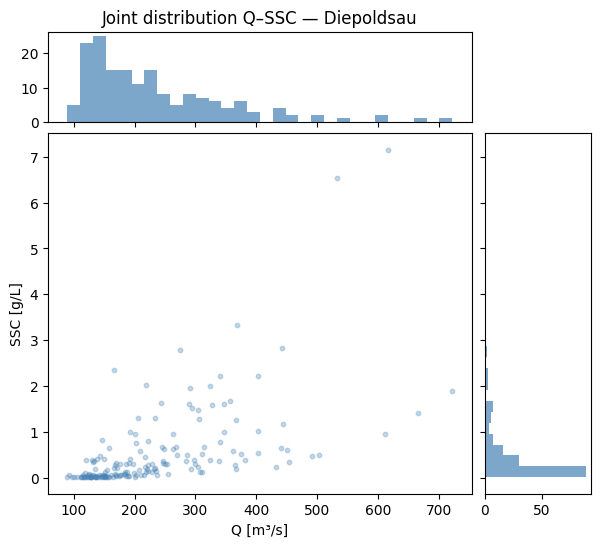

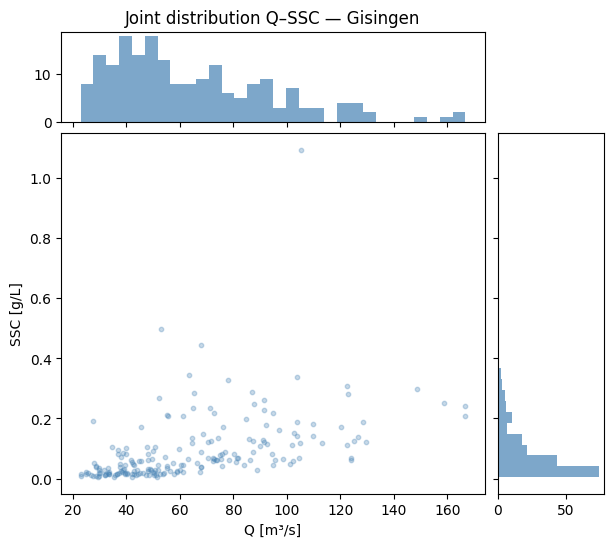

In [ ]:
# PLOT
from utils import plot_joint_distribution

plot_joint_distribution(q_diep, ssc_diep, title="Joint distribution Q–SSC — Diepoldsau")
plot_joint_distribution(q_gis,  ssc_gis,  title="Joint distribution Q–SSC — Gisingen")
plt.show()

In [ ]:
# PRINT
df5 = pd.DataFrame([
    {"Station": "Diepoldsau", **corr_diep},
    {"Station": "Gisingen",   **corr_gis},
])
df5 = df5.rename(columns={"pearson_r": "Pearson r", "pearson_p": "Pearson p",
                            "spearman_r": "Spearman r", "spearman_p": "Spearman p"})
for col in ["Pearson r", "Pearson p", "Spearman r", "Spearman p"]:
    df5[col] = df5[col].map("{:.4f}".format)
print(df5.to_string(index=False))

   Station Pearson r Pearson p Spearman r Spearman p
Diepoldsau    0.5837    0.0000     0.7381     0.0000
  Gisingen    0.4696    0.0000     0.6762     0.0000


**Comments — Section 5**

**Can Q and C be considered statistically independent?**
No. Both Pearson (Diepoldsau: r = 0.58, p ≈ 0; Gisingen: r = 0.47, p ≈ 0) and Spearman (Diepoldsau: ρ = 0.74; Gisingen: ρ = 0.68) rank correlations are highly significant at both stations. The Spearman correlation is substantially higher than Pearson, indicating a non-linear (power-law) relationship of the form C = a·Q^b — the classic sediment rating curve. High flows carry disproportionately more sediment, and this dependence cannot be dismissed. Q and C are **not statistically independent**.

**Shortfalls of independent simulation:**
Simulating Q and C with separate uncoupled AR/ARMA models ignores this positive dependence. As a direct consequence: (1) the joint distribution of (Q, C) is not preserved — high-Q/high-C events that dominate sediment transport are underrepresented; (2) the expected value of the product M = E[Q·C] = E[Q]·E[C] + Cov(Q,C) — ignoring the covariance term causes the synthetic M to be biased, in this case upward because the positive correlation would inflate E[Q·C] above E[Q]·E[C]; (3) return periods of extreme sediment loads are incorrectly estimated. This explains the ~18% overestimate of synthetic mass yields observed in Section 4.

**How would you resolve this?**
The most physically meaningful approach is a **sediment rating curve** (log C = log a + b·log Q), which directly encodes the Q–C dependency and reduces the problem to modelling only one stochastic variable (Q). Alternatively, a **bivariate VAR(p) model** or a **copula-based approach** (e.g. Gaussian or Clayton copula) would jointly simulate Q and C while preserving both the marginal temporal autocorrelation structures and the cross-correlation between variables.